# Pipeline Huấn luyện & Đánh giá — ShieldAI (PhoBERT + Hybrid MLP)

Notebook **duy nhất** gom toàn bộ quy trình (trước đây tách thành 4 file):

| Phần | Nội dung |
|------|----------|
| **0** | Phương pháp hybrid & cấu hình PhoBERT (lý thuyết + minh họa) |
| **1** | Tiền xử lý & lọc dữ liệu (`dataset_cleaner`) |
| **2** | Nhúng PhoBERT-base → lưu `.npy` |
| **3** | Metadata phi văn bản (mô phỏng MXH + thống kê văn bản) |
| **4** | Ghép vector & huấn luyện MLP → lưu `.joblib` |
| **5** | Kết quả thực nghiệm (confusion matrix, ablation, ROC, 5-fold CV) |

> `REGENERATE_EMBEDDINGS = False` nếu đã có `phobert_base_features.npy` (tránh chạy lại ~1 giờ trên CPU).
> Metadata MXH được **mô phỏng** — cần ghi chú trong luận văn.


In [1]:
# !pip install pyvi transformers torch pandas numpy seaborn matplotlib tqdm scikit-learn joblib

import joblib
from pathlib import Path
import sys

# Đảm bảo import được package `backend/` dù Jupyter chạy ở thư mục nào
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [_cwd, *_cwd.parents] if (p / "backend" / "__init__.py").exists()), _cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from pyvi import ViTokenizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

from backend.dataset_cleaner import prepare_training_dataset, add_segmented_column

REGENERATE_EMBEDDINGS = False  # True = chạy lại embedding PhoBERT

FEATURES_PATH = PROJECT_ROOT / 'backend/models/phobert_base_features.npy'
LABELS_PATH = PROJECT_ROOT / 'backend/models/phobert_base_labels.npy'
DATA_PATH = PROJECT_ROOT / 'backend/data/full_dataset.csv'

np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


PROJECT_ROOT = /home/haminhchien/Documents/DoAnTotNghiep
Device: cpu


## Phần 0 — Phương pháp lai & cấu hình PhoBERT

### 0.1. Tiếp cận đa phương thức (Hybrid)
Kết hợp **đặc trưng nội dung** (PhoBERT 768 chiều) và **metadata ngữ cảnh** (10 chiều: 5 MXH mô phỏng + 5 thống kê văn bản).

### 0.2. Kiến trúc & hyperparameters (tham khảo fine-tune)
Đề tài dùng **PhoBERT-base frozen** + MLP; bảng dưới mô tả cấu hình nếu fine-tune end-to-end:

| Thông số | Giá trị điển hình |
|----------|-------------------|
| Model | `vinai/phobert-base` (12 layers, 768 hidden) |
| Learning rate | `2e-5` |
| Batch size | 16 |
| Epochs | 5 |
| Optimizer | AdamW |
| LR scheduler | linear |


In [2]:
from transformers import AutoConfig, AutoModelForSequenceClassification, TrainingArguments

model_name = 'vinai/phobert-base'
config = AutoConfig.from_pretrained(model_name)
print('==== KIẾN TRÚC PHOBERT-BASE ====')
print(f'- Hidden layers: {config.num_hidden_layers}')
print(f'- Hidden size: {config.hidden_size}')
print(f'- Attention heads: {config.num_attention_heads}')
print(f'- Vocab size: {config.vocab_size}')

_ = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
print('[+] Khởi tạo PhoBERT cho classification (2 nhãn) — tham khảo kiến trúc.')

training_args = TrainingArguments(
    output_dir='./results_fake_news',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    optim='adamw_torch',
    lr_scheduler_type='linear',
    seed=42,
    eval_strategy='epoch',
    save_strategy='epoch',
)
print('\n==== HYPERPARAMETERS (fine-tune tham khảo) ====')
print(f'LR={training_args.learning_rate}, batch={training_args.per_device_train_batch_size}, epochs={training_args.num_train_epochs}')


==== KIẾN TRÚC PHOBERT-BASE ====
- Hidden layers: 12
- Hidden size: 768
- Attention heads: 12
- Vocab size: 64001


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

[+] Khởi tạo PhoBERT cho classification (2 nhãn) — tham khảo kiến trúc.

==== HYPERPARAMETERS (fine-tune tham khảo) ====
LR=2e-05, batch=16, epochs=5


In [3]:
from transformers import AutoTokenizer

demo_tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')

def phobert_preprocess(text: str):
    segmented = ViTokenizer.tokenize(text)
    encoded = demo_tokenizer(
        segmented, padding='max_length', truncation=True, max_length=256, return_tensors='pt'
    )
    return segmented, encoded

raw_news = 'Công an thành phố Hà Nội vừa triệt phá một đường dây tung tin đồn thất thiệt trên mạng xã hội.'
segmented_news, bpe_encoded = phobert_preprocess(raw_news)
print('[+] Văn bản gốc:', raw_news)
print('[+] Tách từ (PyVi):', segmented_news)
print('[+] Token IDs (15 đầu):', bpe_encoded['input_ids'][0].tolist()[:15])


[+] Văn bản gốc: Công an thành phố Hà Nội vừa triệt phá một đường dây tung tin đồn thất thiệt trên mạng xã hội.
[+] Tách từ (PyVi): Công_an thành_phố Hà_Nội vừa triệt_phá một đường_dây tung tin_đồn thất_thiệt trên mạng xã_hội .
[+] Token IDs (15 đầu): [0, 367, 214, 120, 164, 9015, 16, 3261, 1360, 2640, 16829, 34, 289, 267, 5]


## Phần 1 — Nạp và lọc dữ liệu

In [4]:
df = prepare_training_dataset(DATA_PATH, add_segmented=False)
print(f'Tổng số tin bài: {len(df)}')


[dataset_cleaner] Gốc: 10617 dòng → sau lọc: 10609 dòng
Tổng số tin bài: 10609


## Phần 2 — PhoBERT: Tách từ & Nhúng (Embedding)

In [5]:
need_embed = REGENERATE_EMBEDDINGS or not (FEATURES_PATH.exists() and LABELS_PATH.exists())

if need_embed:
    print('Đang tách từ...')
    df = add_segmented_column(df)
    print(df[['content', 'content_segmented']].head(2))
else:
    print('Bỏ qua embedding — dùng file .npy có sẵn.')


Bỏ qua embedding — dùng file .npy có sẵn.


In [6]:
if need_embed:
    print('Đang tải PhoBERT-base...')
    tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')
    model = AutoModel.from_pretrained('vinai/phobert-base', output_attentions=True).to(device)
    model.eval()

    def get_phobert_embeddings(texts, batch_size=32, max_len=256):
        all_embeddings = []
        with torch.no_grad():
            for i in tqdm(range(0, len(texts), batch_size), desc='Embedding'):
                batch = texts[i:i + batch_size]
                encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors='pt')
                input_ids = encoded['input_ids'].to(device)
                attention_mask = encoded['attention_mask'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                all_embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
        return np.vstack(all_embeddings)

    vectors = get_phobert_embeddings(df['content_segmented'].tolist())
    print(f'Kích thước embedding: {vectors.shape}')
    np.save(FEATURES_PATH, vectors)
    np.save(LABELS_PATH, df['is_fake'].values)
    print(f'Đã lưu: {FEATURES_PATH.name}, {LABELS_PATH.name}')


### (Tùy chọn) Trực quan Attention

In [7]:
# Chỉ chạy khi vừa embed (model + tokenizer đã load)
if need_embed:
    sample = 'Mạng xã hội chấn_động khi xuất_hiện tin_đồn nam ca_sĩ nổi_tiếng đột_tử trong đêm.'
    inputs = tokenizer(sample, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    attention = outputs.attentions[-1][0, 0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap='YlOrRd')
    plt.title('Self-Attention PhoBERT (minh họa)')
    plt.show()


## Phần 3 — Metadata phi văn bản & thống kê văn bản

Metadata người dùng/lan truyền được **mô phỏng** vì `full_dataset.csv` không có cột MXH thật.


In [8]:
from backend.feature_extraction import ALL_META_COLS, add_metadata_features

df = add_metadata_features(df, random_state=42)
all_meta_columns = ALL_META_COLS
df[['is_fake'] + all_meta_columns].sample(5)


,is_fake,account_age_days,followers,is_verified,share_speed,angry_ratio,title_length,uppercase_ratio,exclamation_count,question_count,punctuation_density
7690,True,938.0,11332.0,0.0,32.316023,0.447077,95,0.024364,0,0,0.008032
3381,True,755.0,7322.0,1.0,17.296101,0.850400,64,0.021148,0,0,0.008308
8818,False,1236.0,16503.0,0.0,23.081025,0.405620,79,0.022133,0,0,0.008853
9614,False,1789.0,17511.0,1.0,5.135295,0.413632,37,0.011767,0,0,0.011224
9503,False,225.0,37746.0,0.0,15.051173,0.585867,18,0.013064,0,0,0.011411


## Phần 4 — Ghép vector & huấn luyện Hybrid MLP

In [9]:
meta_features = df[all_meta_columns].values
scaler_meta = StandardScaler()
meta_features_scaled = scaler_meta.fit_transform(meta_features)

X_phobert = np.load(FEATURES_PATH)
y_labels = np.load(LABELS_PATH)
assert len(meta_features) == len(X_phobert) == len(y_labels), 'Số dòng không khớp'

X_combined = np.hstack((X_phobert, meta_features_scaled))
print(f'PhoBERT: {X_phobert.shape} | Meta: {meta_features_scaled.shape} | Combined: {X_combined.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)
scaler_combined = StandardScaler()
X_train_scaled = scaler_combined.fit_transform(X_train)
X_test_scaled = scaler_combined.transform(X_test)


PhoBERT: (10609, 768) | Meta: (10609, 10) | Combined: (10609, 778)


In [10]:
print('Huấn luyện MLP Classifier...')
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    alpha=0.1,
    early_stopping=True,
    random_state=42,
)
mlp_model.fit(X_train_scaled, y_train)

y_pred = mlp_model.predict(X_test_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

MODELS_DIR = PROJECT_ROOT / 'backend/models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(mlp_model, MODELS_DIR / 'hybrid_mlp_model.joblib')
joblib.dump(scaler_combined, MODELS_DIR / 'hybrid_scaler.joblib')
joblib.dump(scaler_meta, MODELS_DIR / 'hybrid_scaler_meta.joblib')
print('Đã lưu vào backend/models/: hybrid_mlp_model.joblib, hybrid_scaler.joblib, hybrid_scaler_meta.joblib')


Huấn luyện MLP Classifier...


Accuracy: 0.9768
              precision    recall  f1-score   support

       False       0.98      0.97      0.98      1706
        True       0.97      0.98      0.98      1477

    accuracy                           0.98      3183
   macro avg       0.98      0.98      0.98      3183
weighted avg       0.98      0.98      0.98      3183

Đã lưu vào backend/models/: hybrid_mlp_model.joblib, hybrid_scaler.joblib, hybrid_scaler_meta.joblib


## Phần 5 — Kết quả thực nghiệm

Đánh giá: confusion matrix, so sánh chỉ-văn-bản vs hybrid, ablation metadata, ROC/AUC, 5-fold CV.

Script: `backend/experiments/run_experimental_evaluation.py`

In [12]:
from IPython.display import Image, display

EXPERIMENTS_DIR = PROJECT_ROOT / 'backend/experiments'
FIG_DIR = EXPERIMENTS_DIR / 'figures' / 'experimental'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not (FIG_DIR / 'cv_summary.csv').exists():
    print('Chạy đánh giá thực nghiệm (~3–8 phút)...')
    from backend.experiments.run_experimental_evaluation import main as run_experiments
    run_experiments()
else:
    print('Dùng kết quả có sẵn tại', FIG_DIR)

df_metrics = pd.read_csv(FIG_DIR / 'metrics_summary.csv')
df_cv = pd.read_csv(FIG_DIR / 'cv_summary.csv')
display(df_metrics)
df_cv


Dùng kết quả có sẵn tại /home/haminhchien/Documents/DoAnTotNghiep/backend/experiments/figures/experimental


,model,n_features,accuracy,precision,recall,f1,roc_auc
0,1. Chỉ văn bản (PhoBERT),768,0.941250,0.932886,0.941097,0.936973,0.984615
1,2. Hybrid đầy đủ (PhoBERT + 10 meta),778,0.976751,0.969859,0.980366,0.975084,0.997116
2,3. PhoBERT + Metadata người dùng (5),773,0.972039,0.963904,0.976303,0.970064,0.996748
3,4. PhoBERT + Thống kê văn bản (5),773,0.948162,0.940860,0.947867,0.944351,0.988487
4,5. Chỉ metadata (10) — không PhoBERT,10,0.959158,0.945731,0.967502,0.956493,0.991250
5,6. Chỉ metadata người dùng (5),5,0.928998,0.890206,0.966148,0.926623,0.977161
6,7. Chỉ thống kê văn bản (5),5,0.826893,0.801825,0.832769,0.817004,0.906161


,model,n_features,accuracy_mean,accuracy_std,accuracy_folds,precision_mean,precision_std,precision_folds,recall_mean,recall_std,recall_folds,f1_mean,f1_std,f1_folds,roc_auc_mean,roc_auc_std,roc_auc_folds
0,1. Chỉ văn bản (PhoBERT),768,0.937411,0.002827,"[0.94062205466541, 0.9354382657869934, 0.94062...",0.930719,0.005766,"[0.9378185524974516, 0.9248496993987976, 0.931...",0.934806,0.008086,"[0.934010152284264, 0.9370558375634518, 0.9411...",0.932716,0.003213,"[0.9359104781281791, 0.9309127584467978, 0.936...",0.983486,0.001641,"[0.984017518717437, 0.9831719414792691, 0.9863..."
1,2. Hybrid đầy đủ (PhoBERT + 10 meta),778,0.974738,0.002777,"[0.9783223374175306, 0.971253534401508, 0.9759...",0.971885,0.005697,"[0.9766497461928934, 0.9782608695652174, 0.971...",0.973803,0.007245,"[0.9766497461928934, 0.9593908629441624, 0.976...",0.972808,0.003040,"[0.9766497461928934, 0.9687339825730394, 0.974...",0.996658,0.000905,"[0.9970141390871873, 0.9959524798092763, 0.997..."
2,3. PhoBERT + Metadata người dùng (5),773,0.970685,0.005142,"[0.9792648444863337, 0.9637134778510839, 0.972...",0.967570,0.005723,"[0.9786368260427264, 0.9623217922606925, 0.966...",0.969333,0.006006,"[0.9766497461928934, 0.9593908629441624, 0.973...",0.968447,0.005550,"[0.9776422764227642, 0.9608540925266904, 0.970...",0.996110,0.000719,"[0.997099857582292, 0.9950836871453509, 0.9964..."
3,4. PhoBERT + Thống kê văn bản (5),773,0.947026,0.005326,"[0.9538171536286523, 0.9486333647502356, 0.950...",0.947318,0.007141,"[0.957688338493292, 0.9506172839506173, 0.9490...",0.938057,0.005196,"[0.9421319796954315, 0.9380710659898477, 0.945...",0.942658,0.005708,"[0.9498464687819856, 0.9443025038323966, 0.947...",0.987589,0.001548,"[0.9895253784784074, 0.9868832844470041, 0.989..."
4,5. Chỉ metadata (10) — không PhoBERT,10,0.958055,0.004307,"[0.9632422243166824, 0.9505183788878416, 0.959...",0.935305,0.006238,"[0.9441723800195886, 0.925531914893617, 0.9360...",0.977254,0.003052,"[0.9786802030456853, 0.9715736040609138, 0.980...",0.955814,0.004448,"[0.9611166500498505, 0.9479940564635958, 0.957...",0.992588,0.001189,"[0.9942398957091643, 0.990530784993906, 0.9928..."
5,6. Chỉ metadata người dùng (5),5,0.927891,0.004703,"[0.9311969839773798, 0.9236569274269557, 0.928...",0.883667,0.007150,"[0.8824065633546034, 0.8737511353315168, 0.891...",0.972785,0.007562,"[0.9827411167512691, 0.9766497461928934, 0.963...",0.926053,0.004766,"[0.9298751200768491, 0.9223394055608821, 0.925...",0.978988,0.001950,"[0.9801579541852501, 0.9795918549571632, 0.978..."
6,7. Chỉ thống kê văn bản (5),5,0.823546,0.004271,"[0.8298774740810556, 0.820923656927427, 0.8218...",0.799795,0.009940,"[0.808910891089109, 0.784037558685446, 0.79667...",0.827171,0.011777,"[0.8294416243654822, 0.8477157360406091, 0.827...",0.813130,0.004186,"[0.819047619047619, 0.8146341463414634, 0.8117...",0.902235,0.005087,"[0.9101688029322867, 0.9020942992736249, 0.899..."


### 5.1. Confusion matrix

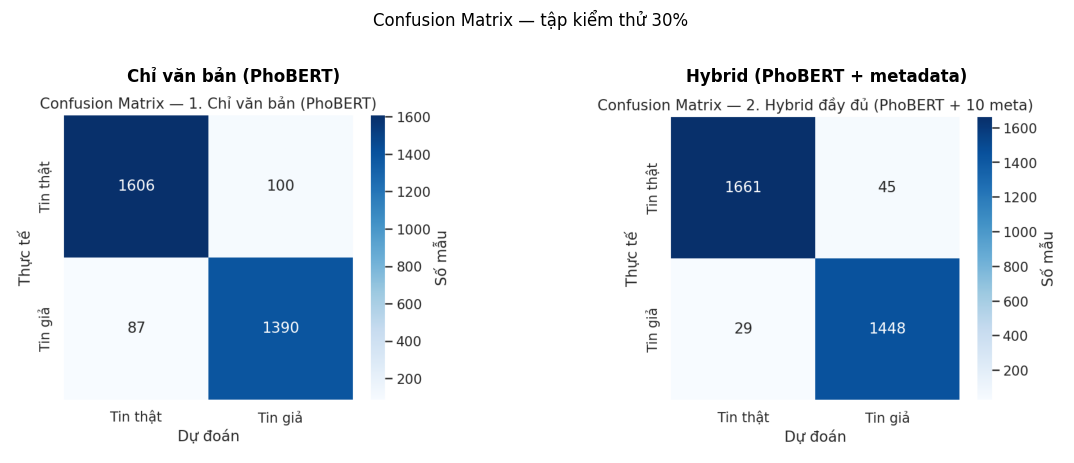

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, name, fname in zip(
    axes,
    ['Chỉ văn bản (PhoBERT)', 'Hybrid (PhoBERT + metadata)'],
    ['confusion_matrix_text_only.png', 'confusion_matrix_hybrid_full.png'],
):
    img = plt.imread(FIG_DIR / fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrix — tập kiểm thử 30%', y=1.02)
plt.tight_layout()
plt.show()


### 5.2. So sánh chỉ-văn-bản vs Hybrid

,model,n_features,accuracy,precision,recall,f1,roc_auc
0,1. Chỉ văn bản (PhoBERT),768,0.941250,0.932886,0.941097,0.936973,0.984615
1,2. Hybrid đầy đủ (PhoBERT + 10 meta),778,0.976751,0.969859,0.980366,0.975084,0.997116


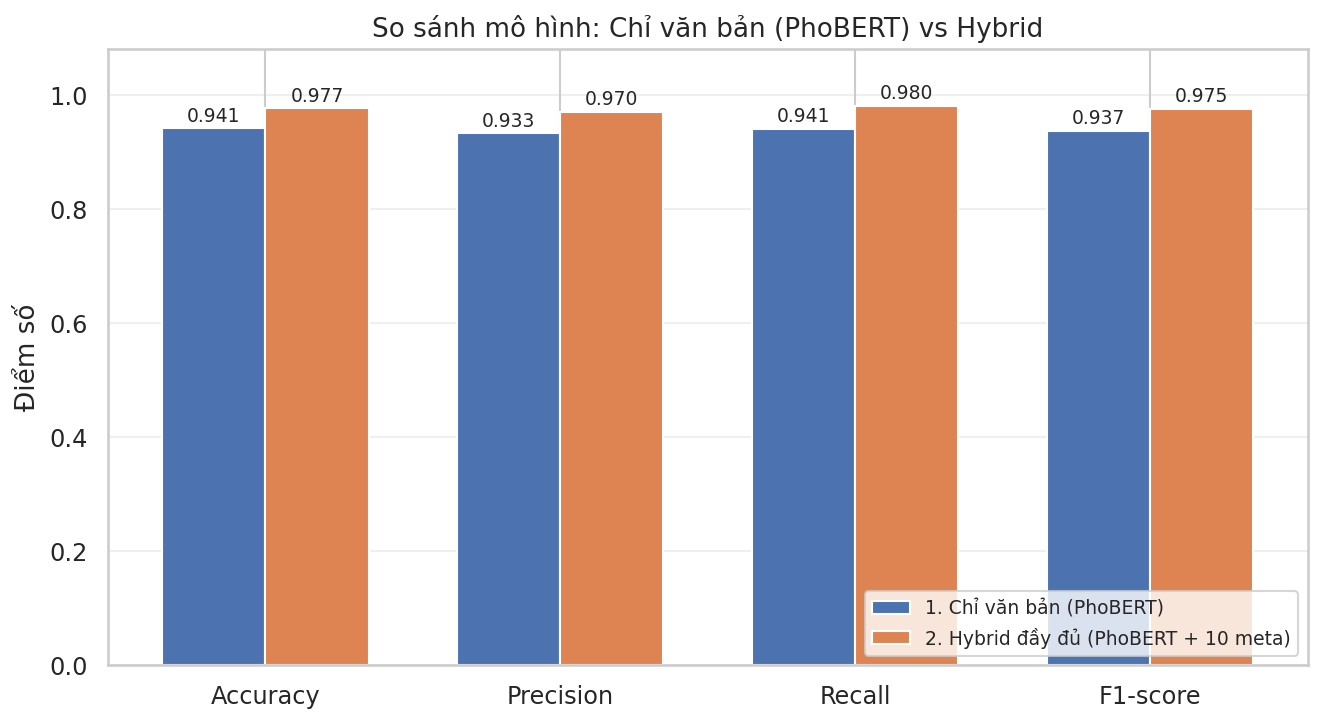

In [14]:
compare = df_metrics[df_metrics['model'].str.contains('Chỉ văn bản|Hybrid đầy đủ')]
display(compare)
display(Image(filename=str(FIG_DIR / 'comparison_text_vs_hybrid.png')))


### 5.3. Ablation study

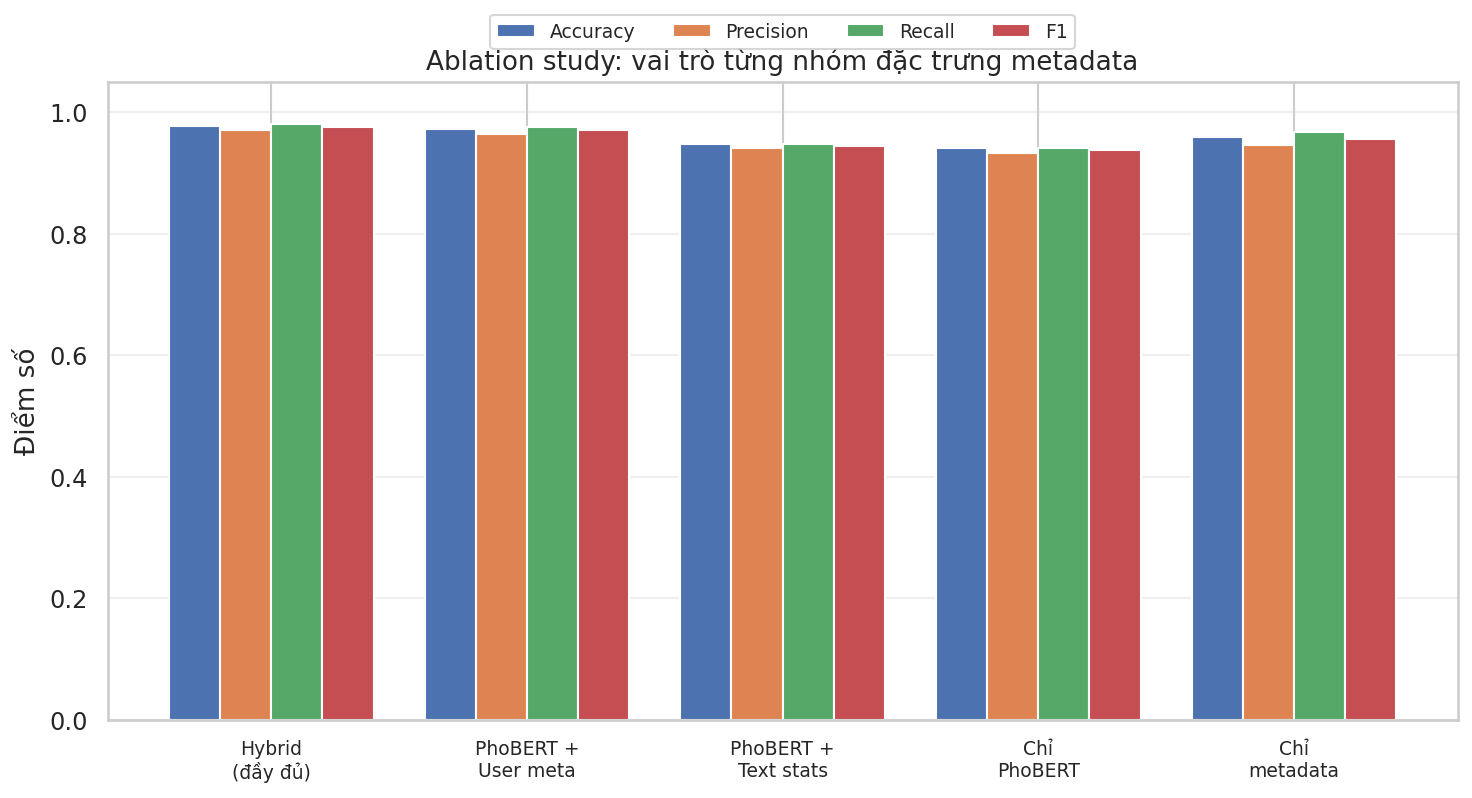

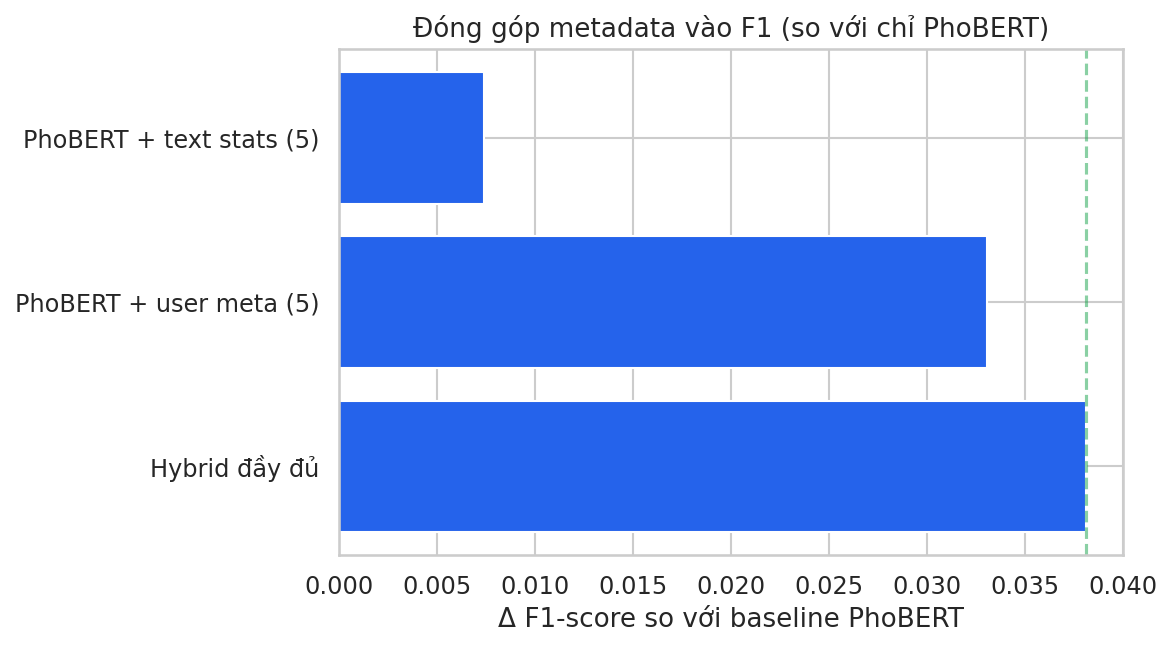

,model,n_features,f1,delta_f1_vs_text_only
1,2. Hybrid đầy đủ (PhoBERT + 10 meta),778,0.975084,0.038111
2,3. PhoBERT + Metadata người dùng (5),773,0.970064,0.033091
4,5. Chỉ metadata (10) — không PhoBERT,10,0.956493,0.019519
3,4. PhoBERT + Thống kê văn bản (5),773,0.944351,0.007377
0,1. Chỉ văn bản (PhoBERT),768,0.936973,0.000000
5,6. Chỉ metadata người dùng (5),5,0.926623,-0.010350
6,7. Chỉ thống kê văn bản (5),5,0.817004,-0.119969


In [15]:
display(Image(filename=str(FIG_DIR / 'ablation_metadata_groups.png')))
display(Image(filename=str(FIG_DIR / 'ablation_f1_delta.png')))
ablation = df_metrics.copy()
baseline_f1 = ablation.loc[ablation['model'].str.contains('Chỉ văn bản'), 'f1'].values[0]
ablation['delta_f1_vs_text_only'] = ablation['f1'] - baseline_f1
ablation[['model', 'n_features', 'f1', 'delta_f1_vs_text_only']].sort_values('f1', ascending=False)
